<a href="https://colab.research.google.com/github/JonPaulBIlbao/Machine-Learning-in-Finance-Python-2026/blob/main/02_04_PCA_IBEX_35.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Machine Learning in Finance**
# **Deusto Business School**

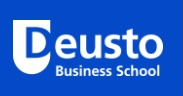

Bachelor degree in Business Administration + Financial Analyst Basics

Second year

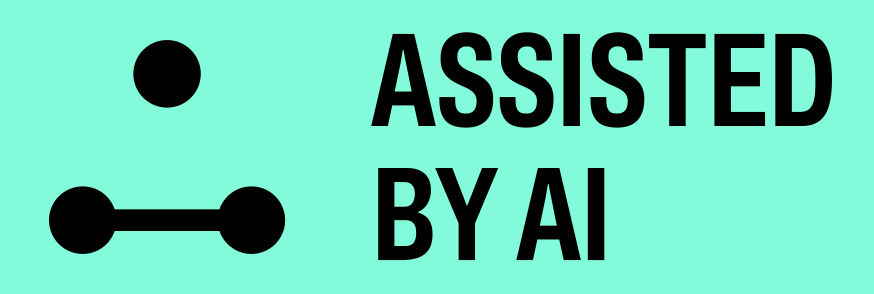

<small style="color: #666;">
  Assisted by AI (content preparation and code support)
</small>


# **Principal Component Analysis (PCA)**

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# IBEX 35: Sector Analysis & Composition (March 2026)

The following table organizes the 35 current constituents of the Spanish benchmark index by their respective economic sectors. This classification is essential for analyzing sector-specific variance in our PCA model.

| Sector | Firm Name | Ticker |
| :--- | :--- | :--- |
| **Banking & Finance** | Banco Santander | `SAN.MC` |
| | BBVA | `BBVA.MC` |
| | CaixaBank | `CABK.MC` |
| | Banco Sabadell | `SAB.MC` |
| | Bankinter | `BKT.MC` |
| | Unicaja Banco | `UNI.MC` |
| | Mapfre (Insurance) | `MAP.MC` |
| **Energy & Utilities** | Iberdrola | `IBE.MC` |
| | Naturgy | `NTGY.MC` |
| | Endesa | `ELE.MC` |
| | Redeia (formerly REE) | `RED.MC` |
| | Enagás | `ENG.MC` |
| | Repsol (Oil & Gas) | `REP.MC` |
| | Acciona Energía | `ANE.MC` |
| | Solaria (Renewables) | `SLR.MC` |
| **Construction & Infrastructure** | ACS Group | `ACS.MC` |
| | Ferrovial | `FER.MC` |
| | Acciona | `ANA.MC` |
| | Sacyr | `SCYR.MC` |
| **Tourism & Transport** | Aena (Airports) | `AENA.MC` |
| | IAG (Airlines) | `IAG.MC` |
| | Amadeus (Travel Tech) | `AMS.MC` |
| **Consumer & Retail** | Inditex (Zara) | `ITX.MC` |
| | Puig Brands (Luxury) | `PUIG.MC` |
| | Logista (Logistics) | `LOG.MC` |
| **Technology & Telecom** | Telefónica | `TEF.MC` |
| | Cellnex Telecom | `CLNX.MC` |
| | Indra Sistemas | `IDR.MC` |
| **Real Estate (SOCIMIs)** | Merlin Properties | `MRL.MC` |
| | Inmobiliaria Colonial | `COL.MC` |
| **Industrial & Healthcare** | ArcelorMittal (Steel) | `MTS.MC` |
| | Acerinox (Stainless Steel) | `ACX.MC` |
| | Grifols (Biotech) | `GRF.MC` |
| | Laboratorios Rovi (Pharma) | `ROVI.MC` |
| | Fluidra (Pool Equipment) | `FDR.MC` |

---
*Note: In our current PCA analysis, tickers with recent IPOs or significant missing data (e.g., PUIG.MC, ANE.MC) may be filtered out depending on the timeframe of the study.*

In [ ]:
# Full list of current IBEX 35 Tickers
ibex35_list = [
    "ANA.MC", "ANE.MC", "ACX.MC", "ACS.MC", "AENA.MC", "AMS.MC",
    "BBVA.MC", "BKT.MC", "CABK.MC", "CLNX.MC", "COL.MC", "ELE.MC",
    "ENG.MC", "FDR.MC", "FER.MC", "GRF.MC", "IAG.MC", "IBE.MC",
    "IDR.MC", "ITX.MC", "LOG.MC", "MAP.MC", "MRL.MC", "MTS.MC",
    "NTGY.MC", "PUIG.MC", "RED.MC", "REP.MC", "ROVI.MC", "SAB.MC",
    "SAN.MC", "SCYR.MC", "SLR.MC", "TEF.MC", "UNI.MC"
]

In [ ]:
sector_map = {
    # Banking & Finance
    "SAN.MC": "Banking", "BBVA.MC": "Banking", "CABK.MC": "Banking",
    "SAB.MC": "Banking", "BKT.MC": "Banking", "UNI.MC": "Banking", "MAP.MC": "Banking",

    # Energy & Utilities
    "IBE.MC": "Energy", "NTGY.MC": "Energy", "ELE.MC": "Energy",
    "RED.MC": "Energy", "ENG.MC": "Energy", "REP.MC": "Energy",
    "ANE.MC": "Energy", "SLR.MC": "Energy",

    # Construction & Infrastructure
    "ACS.MC": "Construction", "FER.MC": "Construction",
    "ANA.MC": "Construction", "SCYR.MC": "Construction",

    # Tourism & Transport
    "AENA.MC": "Tourism", "IAG.MC": "Tourism", "AMS.MC": "Tourism",

    # Consumer & Retail
    "ITX.MC": "Retail", "PUIG.MC": "Retail", "LOG.MC": "Retail",

    # Technology & Telecom
    "TEF.MC": "Tech", "CLNX.MC": "Tech", "IDR.MC": "Tech",

    # Real Estate
    "MRL.MC": "Real Estate", "COL.MC": "Real Estate",

    # Industrial & Healthcare
    "MTS.MC": "Industrial", "ACX.MC": "Industrial",
    "GRF.MC": "Industrial", "ROVI.MC": "Industrial", "FDR.MC": "Industrial"
}

## Download Stock Prices from Yahoo Finance

In [ ]:
# Download data for all tickers using yfinance
prices = yf.download(ibex35_list,
                     start="2020-01-01",
                     end="2026-02-28",
                     group_by='ticker',
                     auto_adjust=True,
                     threads=True)


[*********************100%***********************]  35 of 35 completed


In [ ]:
prices.head()

Ticker        MRL.MC                                           IAG.MC  \
Price           Open      High       Low     Close   Volume      Open   
Date                                                                    
2020-01-02  9.345808  9.345808  9.251552  9.287805   460980  4.692727   
2020-01-03  9.244300  9.295053  9.215298  9.295053  1432326  4.690179   
2020-01-06  9.215298  9.295053  9.150044  9.266051   532601  4.611181   
2020-01-07  9.295053  9.309554  9.157295  9.215299   653971  4.574230   
2020-01-08  9.179046  9.200798  9.099292  9.113792   966373  4.574230   

Ticker                                              ...     MTS.MC             \
Price           High       Low     Close    Volume  ...       Open       High   
Date                                                ...                         
2020-01-02  4.774274  4.691454  4.761532  26533493  ...  14.545692  14.806453   
2020-01-03  4.701647  4.611181  4.659599   5332872  ...  14.341858  14.341858   
2020-01-06  4.611181  4.474846  4.552570   4237650  ...  13.754226  13.825844   
2020-01-07  4.653228  4.566585  4.622648   3560936  ...  13.897462  13.985607   
2020-01-08  4.644309  4.491410  4.639212   3892033  ...  13.726680  14.037023   

Ticker                                      BKT.MC                      \
Price             Low      Close  Volume      Open      High       Low   
Date                                                                     
2020-01-02  14.543856  14.545692  467429  3.412680  3.451741  3.397261   
2020-01-03  13.985607  14.031515  914342  3.436322  3.436322  3.381843   
2020-01-06  13.500811  13.776262  500168  3.401373  3.443517  3.360256   
2020-01-07  13.746882  13.822172  385006  3.453796  3.466131  3.373619   
2020-01-08  13.649554  13.992950  359652  3.371563  3.396233  3.345865   

Ticker                         
Price          Close   Volume  
Date                           
2020-01-02  3.447629  2828471  
2020-01-03  3.420903  2171133  
2020-01-06  3.437350  2268976  
2020-01-07  3.383898  2842951  
2020-01-08  3.379786  2007961  

[5 rows x 175 columns]

## 📊 Dataset Structure: IBEX 35 Historical Prices

The variable `prices` contains a **Multi-Index DataFrame**. Because the `group_by='ticker'` argument was used, the data is organized hierarchically.

### 1. Hierarchy Levels
* **Level 0 (Columns):** The Ticker Symbol (e.g., `SAN.MC`, `ITX.MC`, `TEF.MC`).
* **Level 1 (Attributes):** Price and Volume data for each ticker:
    * `Open`: The opening price of the trading session.
    * `High`: The maximum price reached.
    * `Low`: The minimum price reached.
    * `Close`: The final adjusted price (due to `auto_adjust=True`).
    * `Volume`: The number of shares traded.

### 2. Temporal Index
* **Rows (Index):** A `DatetimeIndex` representing each trading day from **January 1, 2020**, to **February 28, 2026**.

### 3. Key Parameters Used
* **`auto_adjust=True`**: Automatically adjusts the Close prices for dividends and stock splits.
* **`group_by='ticker'`**: Ensures all OHLCV data for a single company is grouped together under one header.

> **Technical Note:** This structure is a "Wide" format, which is efficient for vectorized operations in Python.

In [ ]:
# prompt: Show summary of prices

# Summarize the prices data
print(prices.describe())

Ticker       MRL.MC                                                       \
Price          Open         High          Low        Close        Volume   
count   1577.000000  1577.000000  1577.000000  1577.000000  1.577000e+03   
mean       8.340924     8.429650     8.240013     8.335397  9.760720e+05   
std        2.095842     2.102271     2.094235     2.102277  7.649732e+05   
min        4.207596     4.281543     4.096675     4.237175  2.482000e+04   
25%        6.978711     7.053233     6.897530     6.975128  5.739070e+05   
50%        7.840996     7.933554     7.737076     7.830457  7.680020e+05   
75%        9.723595     9.851702     9.657384     9.751971  1.071565e+06   
max       14.500000    15.360000    14.360000    15.010000  8.411916e+06   

Ticker       IAG.MC                                                       ...  \
Price          Open         High          Low        Close        Volume  ...   
count   1577.000000  1577.000000  1577.000000  1577.000000  1.577000e+03  ...

In [ ]:
print(prices.columns.levels[1].tolist())

['Close', 'High', 'Low', 'Open', 'Volume']


In [ ]:
print("Level 0 (Ticker Symbols):\n", prices.columns.levels[0].tolist())

Level 0 (Ticker Symbols):
 ['ACS.MC', 'ACX.MC', 'AENA.MC', 'AMS.MC', 'ANA.MC', 'ANE.MC', 'BBVA.MC', 'BKT.MC', 'CABK.MC', 'CLNX.MC', 'COL.MC', 'ELE.MC', 'ENG.MC', 'FDR.MC', 'FER.MC', 'GRF.MC', 'IAG.MC', 'IBE.MC', 'IDR.MC', 'ITX.MC', 'LOG.MC', 'MAP.MC', 'MRL.MC', 'MTS.MC', 'NTGY.MC', 'PUIG.MC', 'RED.MC', 'REP.MC', 'ROVI.MC', 'SAB.MC', 'SAN.MC', 'SCYR.MC', 'SLR.MC', 'TEF.MC', 'UNI.MC']


In [ ]:
print("\nLevel 1 (Financial Metrics):\n", prices.columns.levels[1].tolist())


Level 1 (Financial Metrics):
 ['Close', 'High', 'Low', 'Open', 'Volume']


### 🛠️ Data Engineering: Transforming to "Tidy" Long Format

When we download financial data for multiple tickers, libraries like `yfinance` often return a **Multi-Index DataFrame**. While this is visually organized, it is "wide" and difficult to process for large-scale cleaning and visualization.

We transform the data into a **Long Format** (also known as "Tidy Data") for three critical reasons:

#### 1. Standardization & "Tidy" Principles
In a tidy dataset:
* Each **row** is a single observation (one firm on one specific day).
* Each **column** is a unique variable (`date`, `adjusted_price`, `symbol`).
* This format is the "universal language" for advanced visualization libraries like **Seaborn** and **Plotly**.

#### 2. Ease of Data Cleaning
As we saw earlier, some firms (like *PUIG* or *Acciona Energía*) have shorter histories.
* In a **Wide** format, removing these requires complex column-level slicing.
* In a **Long** format, we can simply filter by row counts or symbol names using standard logic, making our "Survivor" analysis much more intuitive.

#### 3. Professional Pipeline Realism
Most professional financial databases (SQL, Bloomberg, or Kdb+) store price history in **Long format**. By restructuring the data this way, we are simulating a real-world quantitative finance environment where data is queried and filtered rather than just viewed as a static spreadsheet.

---

### Breakdown of the Code:
1.  **Iterate:** We loop through our `ibex35_list` to isolate each firm's data.
2.  **Metadata Tagging:** We explicitly add the `symbol` name as a new column so the data isn't "lost" when we combine the stocks.
3.  **Renaming:** We rename `Close` to `adjusted`. This reminds us that we are using prices adjusted for dividends and splits—the only valid price for calculating returns in research.
4.  **Concatenate:** `pd.concat` stacks all 35 "notebooks" into one single, master ledger.

In [ ]:
# Convert multi-index DataFrame to long format
long_data = []

for symbol in ibex35_list:
    df = prices[symbol].copy()
    df['date'] = df.index
    df['symbol'] = symbol
    df = df[['date', 'Close', 'symbol']].rename(columns={'Close': 'adjusted'})
    long_data.append(df)

prices_df = pd.concat(long_data).reset_index(drop=True)

In [ ]:
prices_df.head()

Price,date,adjusted,symbol
0,2020-01-02,76.969078,ANA.MC
1,2020-01-03,75.804138,ANA.MC
2,2020-01-06,75.096848,ANA.MC
3,2020-01-07,75.096848,ANA.MC
4,2020-01-08,75.055237,ANA.MC


In [ ]:
prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55195 entries, 0 to 55194
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      55195 non-null  datetime64[ns]
 1   adjusted  53700 non-null  float64       
 2   symbol    55195 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.3+ MB


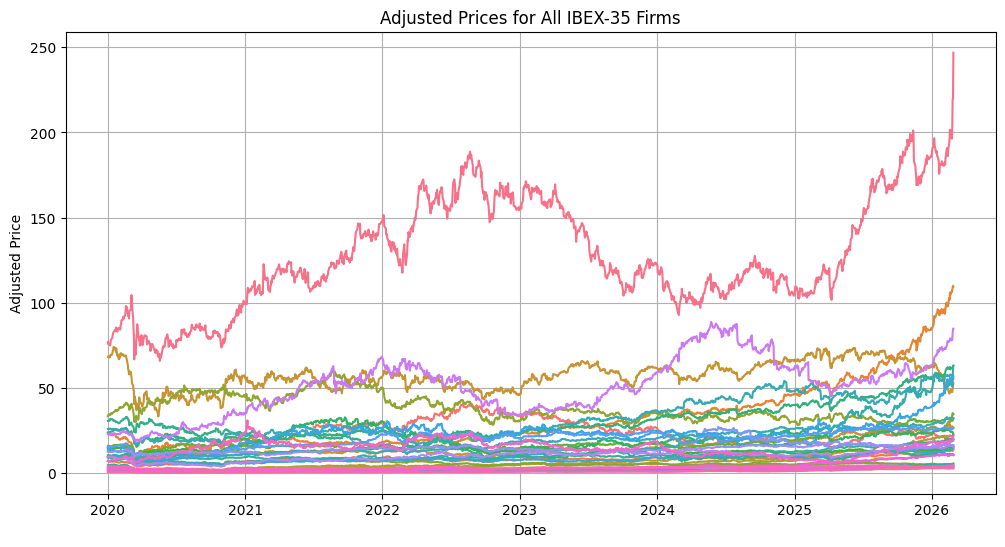

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=prices_df, x="date", y="adjusted", hue="symbol", legend=False)
plt.title("Adjusted Prices for All IBEX-35 Firms")
plt.xlabel("Date")
plt.ylabel("Adjusted Price")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# 1. Pivot the data: 1577 rows (Dates) x 35 columns (Symbols)
wide_df = prices_df.pivot(index='date', columns='symbol', values='adjusted')

# 2. Calculate Log Returns
# log(Pt / Pt-1)
returns_df = np.log(wide_df / wide_df.shift(1))

# We only drop the very first row because EVERY firm has a NaN on day 1
# (since there is no "day 0" to calculate the return).
returns_df = returns_df.iloc[1:]

print(f"Matrix Shape: {returns_df.shape}")
print(f"Total NaNs in matrix: {returns_df.isna().sum().sum()}")

Matrix Shape: (1576, 35)
Total NaNs in matrix: 1496


In [ ]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1576 entries, 2020-01-03 to 2026-02-27
Data columns (total 35 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ACS.MC   1576 non-null   float64
 1   ACX.MC   1576 non-null   float64
 2   AENA.MC  1576 non-null   float64
 3   AMS.MC   1576 non-null   float64
 4   ANA.MC   1576 non-null   float64
 5   ANE.MC   1192 non-null   float64
 6   BBVA.MC  1576 non-null   float64
 7   BKT.MC   1576 non-null   float64
 8   CABK.MC  1576 non-null   float64
 9   CLNX.MC  1576 non-null   float64
 10  COL.MC   1576 non-null   float64
 11  ELE.MC   1576 non-null   float64
 12  ENG.MC   1576 non-null   float64
 13  FDR.MC   1576 non-null   float64
 14  FER.MC   1576 non-null   float64
 15  GRF.MC   1576 non-null   float64
 16  IAG.MC   1576 non-null   float64
 17  IBE.MC   1576 non-null   float64
 18  IDR.MC   1576 non-null   float64
 19  ITX.MC   1576 non-null   float64
 20  LOG.MC   1576 non-null   float64
 

## ⚠️ Why We Must Exclude ANE.MC and PUIG.MC: Statistical & Financial Justification

Based on our dataset summary, we have a significant "Sparse Data" problem. While the majority of the IBEX 35 has **1,576** valid observations, **ANE.MC** only has **1,192** and **PUIG.MC** has a mere **464**.

### 1. Financial Context: IPOs and Spin-offs
The reason for these missing values isn't an error; it's the history of the stock market:
* **PUIG.MC (IPO):** This luxury brand only went public in **May 2024**. It simply did not exist as a traded entity during the first four years of our study.
* **ANE.MC (Spin-off):** Acciona Energía began trading in **July 2021** after being separated from its parent company (Acciona). Because our study begins in **January 2020**, ANE is missing the entire "Pandemic Era" of data.

### 2. Statistical Justification: The "Listwise Deletion" Trap
Standard PCA algorithms require a **complete matrix**. If a single cell in a row contains a `NaN`, the algorithm must discard that entire row.

* **The Consequence:** If we keep **PUIG.MC**, we are forced to delete **70% of our historical data** (everything from Jan 2020 to May 2024). We would lose the critical "Market Stress" data from the COVID-19 crash and the 2022 interest rate shifts just to accommodate one new firm.
* **The ANE Problem:** Even keeping **ANE.MC** would force us to delete the first 1.5 years of the study, meaning we could not analyze how the energy sector behaved during the 2020 global lockdowns.

**Decision:** We exclude these tickers to preserve the "Long-Term Memory" of our model. It is better to have a 33-stock model covering 6 years than a 35-stock model covering only 1 year.

### 2. Financial Justification: Survivorship & Regime Analysis
In finance, PCA is used to identify **Latent Risk Factors** (the "hidden forces" moving the market).

* **Regime Blindness:** By dropping the years 2020–2023 to keep PUIG, we lose the ability to see how the market behaves during high-interest-rate pivots or global lockdowns. A factor model that only knows "Mid-2024 to 2026" is not a robust model for the Spanish economy.
* **IPO Volatility:** Newer firms like **PUIG** (IPO May 2024) often exhibit "price discovery" volatility that is idiosyncratic and unrepresentative of the broader systematic market risk we are trying to capture with PCA.
* **Comparability:** To find a true "IBEX Factor," we need all constituents to have lived through the same economic events. You cannot compare the 5-year beta of Santander with the 1-year beta of Puig and expect a meaningful Eigenvalue decomposition.

---
**Conclusion:** To maintain the integrity of our 2020–2026 analysis, we will proceed with the **33 "Survivor" firms** that provide a continuous, high-fidelity signal of the Spanish market's evolution.

In [ ]:
# 1. Define the columns to remove
cols_to_drop = ["ANE.MC", "PUIG.MC"]

# 2. Create the new returns_df by dropping those columns
# axis=1 tells Pandas we are targeting columns, not rows
returns_df = returns_df.drop(columns=cols_to_drop).copy()

# 3. Final Verification
print("--- Cleaned Dataset Info ---")
print(f"Final columns: {returns_df.shape[1]} (Should be 33)")
print(f"Any remaining NaNs? {returns_df.isna().sum().sum()}")

--- Cleaned Dataset Info ---
Final columns: 33 (Should be 33)
Any remaining NaNs? 0


## Connecting Your "Brain" (Mounting Google Drive)

Before we can save or load any files, we must "mount" your Google Drive. Think of this as plugging a USB drive into a computer—it gives this notebook permission to read and write to your private cloud storage.

### 🛑 Stop and Consolidate
At this exact moment, we pause. Our `returns_df` is perfectly cleaned, filtered, and transformed. It is the "Gold Standard" version of our data. To ensure we never have to wait for downloads or re-run complex cleaning scripts again, we are going to **consolidate and save** this dataframe.

### 📍 The Big Question: WHERE?
We have the data ready, but before we hit "Save," we must define its permanent home.
* Do we save it in a shared folder?
* Your personal drive?
* A specific project directory?

In the next step, we will define the **Path**—the GPS coordinates for your data—so your "Gold Dataset" is always just one line of code away.

### 🛠️ Instructions for Students:
1. **Run the code cell below.**
2. A pop-up window or a link will appear asking for permissions.
3. Select your student Google account and click **"Allow"**.
4. Once you see the message `Mounted at /content/drive`, you are ready to go!

---

In [ ]:
from google.colab import drive

# This initiates the connection to your personal Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/content/drive/MyDrive/Grado Finanzas/25-26/2 - PCA

## Data Persistence: Consolidating Our Gold Dataset

Now that we have successfully cleaned, filtered, and transformed our raw market data into a dense matrix of **33 firms** and **1,576 trading days**, it is a best practice to "freeze" this dataset.

In a professional quantitative pipeline, you do not want to re-run your cleaning scripts every time you open your notebook. Instead, we save the result to a **Parquet file**.

### Why Parquet?
* **Efficiency:** Parquet is a columnar storage format that is significantly faster and smaller than CSV.
* **Metadata Integrity:** Unlike CSV, Parquet preserves our `DatetimeIndex` and data types perfectly. When you reload this file, your dates will already be dates, not strings.
* **Reproducibility:** This ensures that every student in the class is performing PCA on the exact same numerical values.

---

### ⚠️ IMPORTANT: Directory Permissions & Action Required
The code cell below points to our **Class Shared Drive**:
` "/content/drive/Shareddrives/Machine Learning in Finance 2026/02. PCA"`

**Please Note:**
1. **Read-Only Access:** You have permission to **read** from this folder, but you do not have permission to **write** to it.
2. **Do Not Execute Blindly:** If you run the code below without modification, you will receive a `Permission Denied` error.
3. **Action:** To save this data for your own use, you must **change the `save_path` variable** to a folder within your own personal "My Drive" (e.g., `/content/drive/MyDrive/MyPCAProject`).

---

In [ ]:
import os

# Define the directory and filename
save_path = "/content/drive/MyDrive/Grado Finanzas/25-26/2 - PCA"
file_name = "ibex35_returns_2020_2026.parquet"
full_file_path = os.path.join(save_path, file_name)

# Save the dataframe to Parquet
# Note: Parquet handles the 'date' index and 'symbol' columns perfectly
returns_df.to_parquet(full_file_path)

print(f"Success! Dataset saved to: {full_file_path}")

Success! Dataset saved to: /content/drive/MyDrive/Grado Finanzas/25-26/2 - PCA/ibex35_returns_2020_2026.parquet


## 🏁 Phase 1 Complete: The Data is Clean! 🏁

Everything is now **DONE**! We have successfully navigated the "Data Jungle": we've scraped raw prices, transformed them into log returns, handled IPO gaps, and saved our "Gold Dataset" securely to Google Drive.

While we will move into a fresh notebook to perform the actual **Principal Component Analysis (PCA)**, we shouldn't jump into the math blindly. In finance, you must always "look at your data" first.

### 🔎 Exploratory Data Analysis (EDA): The "Visual Audit"

The code below generates a **Faceted Plot** (or "Small Multiples"). We are creating a dedicated window for each of our 33 firms to see their behavior over the last 6 years.

**The Target of this Visual:**
1. **Spotting Systemic Risk:** Notice how every single graph "spikes" at the same time during the March 2020 crash. This is the **Market Factor** in action.
2. **Identifying Volatility Clusters:** You will see that some sectors (like Banks) are much "noisier" than others (like Utilities).
3. **Justifying Standardization:** Because these firms have such different "vertical heights" (volatilities), this plot proves why we must standardize our data before running PCA—otherwise, the most volatile stocks would unfairly dominate our model.

Let's take a final look at the "pulse" of the IBEX 35 before we decompose it into its hidden factors!

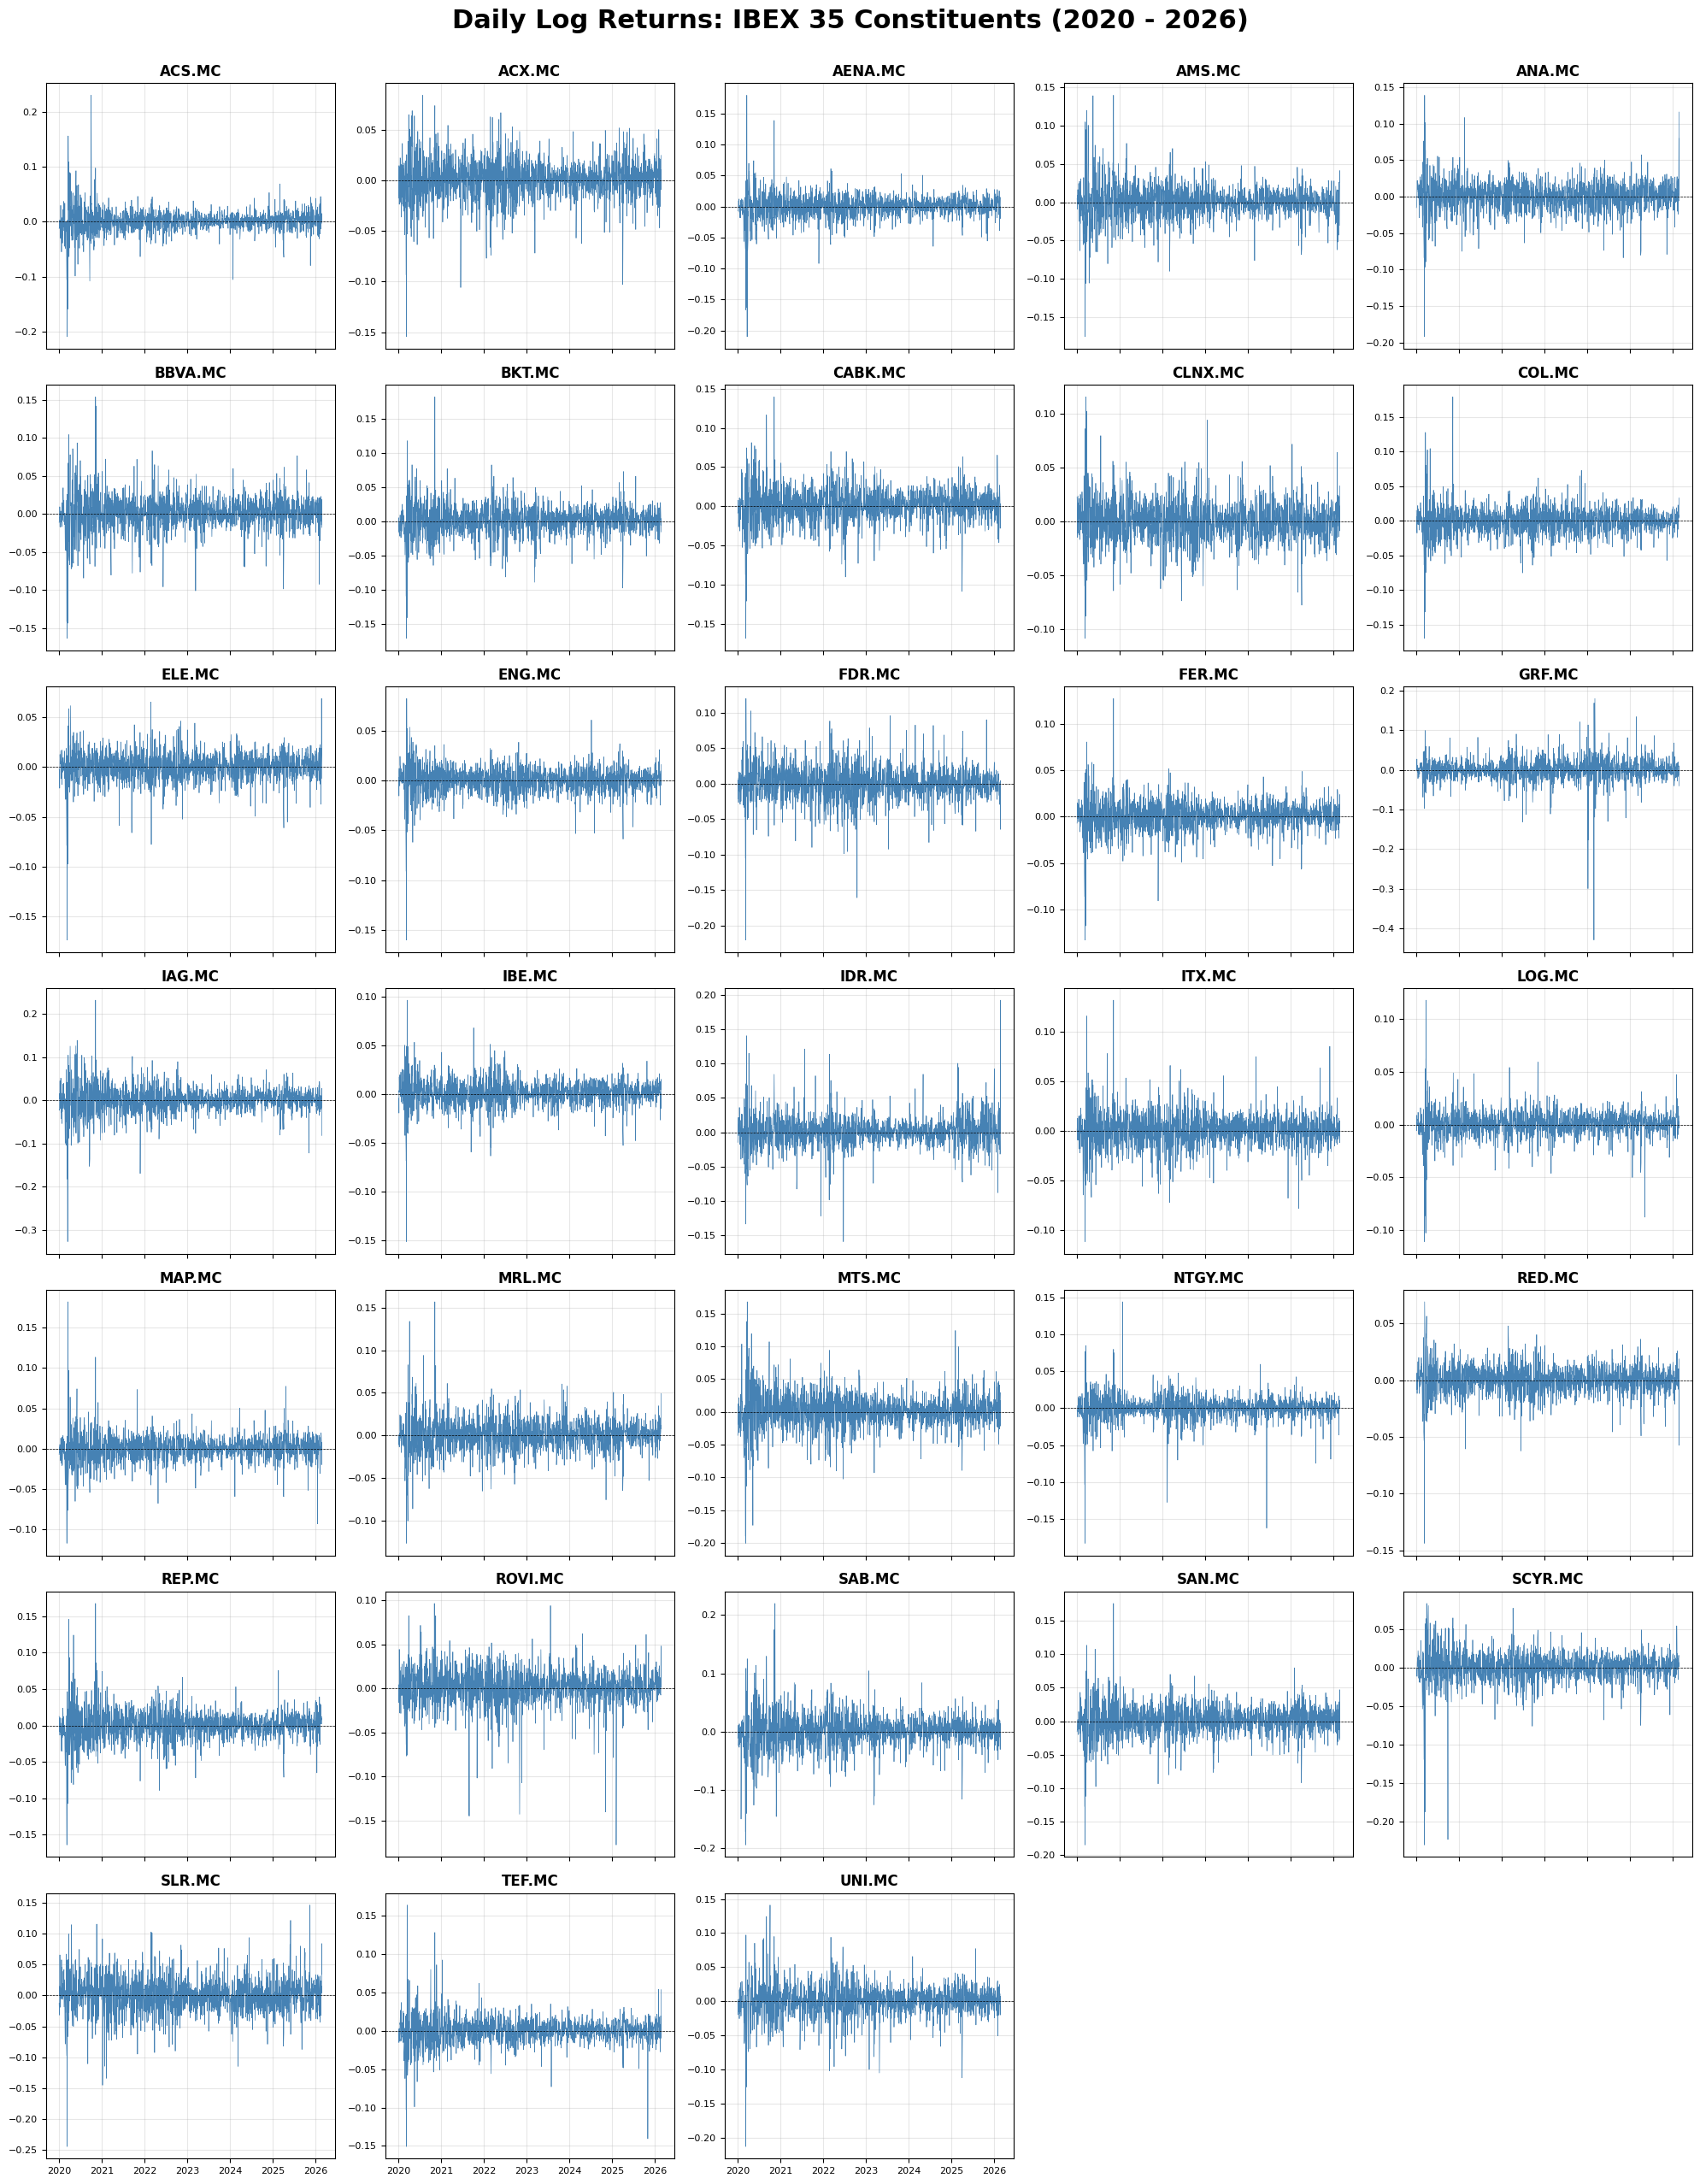

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the figure and grid
# 33 firms fit well in a 7-row by 5-column grid (35 slots total)
fig, axes = plt.subplots(nrows=7, ncols=5, figsize=(20, 25), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 2. Iterate through each firm and plot
for i, col in enumerate(returns_df.columns):
    ax = axes[i]
    ax.plot(returns_df.index, returns_df[col], color='steelblue', lw=0.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Optional: Highlight the zero-line to show gains vs losses
    ax.axhline(0, color='black', lw=0.5, ls='--')

    # Clean up y-axis to save space
    ax.tick_params(axis='both', which='major', labelsize=8)

# 3. Remove the extra empty subplots (since 35 slots > 33 firms)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. Final layout adjustments
plt.tight_layout()
plt.suptitle("Daily Log Returns: IBEX 35 Constituents (2020 - 2026)",
             fontsize=22, y=1.02, fontweight='bold')
plt.show()

## The Market's Nervous System: The Correlation Matrix

Now that we’ve seen the individual "heartbeats" of each firm in our faceted plots, it’s time to see how they pulse **together**. In finance, we aren't just interested in how one stock moves; we want to know if they move in lockstep or if they provide diversification.

The code below generates a **Correlation Heatmap**. This is the final "pre-PCA" check that translates 6 years of daily returns into a single map of relationships.

### 🕵️What to Look For (The "Target"):

* **The Diagonal "Fire":** You will see a perfect red line (correlation of 1.0) cutting through the center. This is simply each firm correlating with itself.
* **The "Heat" (Red Clusters):** Areas of deep red represent stocks that are highly correlated. If you see "blocks" of red, you are likely looking at a **Sector Factor** (e.g., the Banking sector moving as one).
* **The "Cool" (Blue/White Areas):** Light blue or white squares indicate stocks that behave independently. These are the "idiosyncratic" movers—firms that provide diversification because they don't follow the crowd.

### 🚀 Why this leads us to PCA:
If this map shows lots of dark red "blocks," it means our 33 variables are **redundant**. PCA loves redundancy! It will take these correlated groups and squash them into a single, powerful "Principal Component."

**Let’s see where the hidden clusters are hiding!**

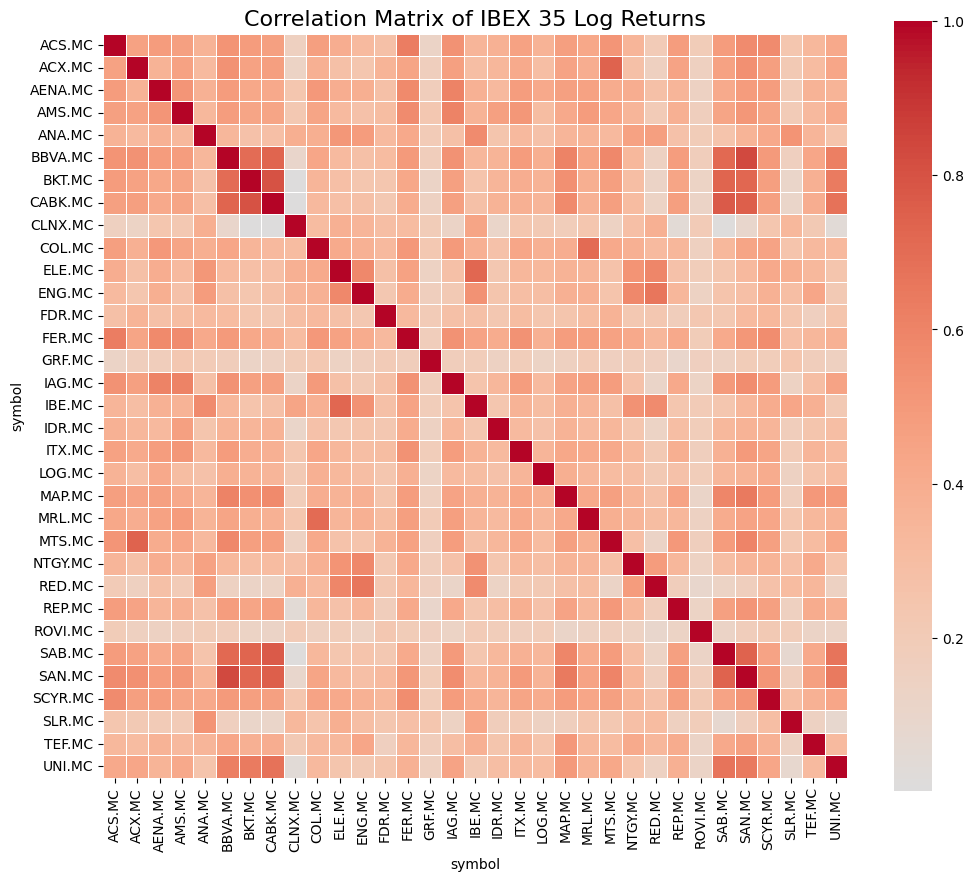

In [ ]:
# Calculate the Correlation Matrix
# Pandas .corr() ignores NaNs automatically (pairwise deletion)
corr_matrix = returns_df.corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=False,       # Turn off numbers to keep it clean (too many firms)
    cmap='coolwarm',   # Red = High Correlation, Blue = Inverse
    center=0,          # Center the colors at 0
    linewidths=0.5,    # Distinct lines between squares
    square=True        # Force squares so it doesn't look stretched
)

plt.title("Correlation Matrix of IBEX 35 Log Returns", fontsize=16)
plt.show()

## Rearranging the tiles: The Clustermap

If you looked at the previous heatmap and thought, *"It's hard to see the patterns because the firms are just in alphabetical order,"* you are exactly right. Alphabetical order is great for dictionaries, but it's terrible for financial analysis.

The code below uses a **Clustermap**. While we will cover the deep math of **Cluster Analysis** in the final module of this semester, you can think of this as a "Smart Sorting" algorithm.

### 🎯 The Aim: Rearranging the Tiles
Instead of listing firms A-Z, the Clustermap performs two clever tricks:
1. **Similarity Grouping:** It calculates which firms have the most similar "correlation profiles" and physically moves their rows and columns so they sit next to each other.
2. **The Dendrogram (The "Tree"):** You will see "branches" on the top and left. These show you the hierarchy of how firms are grouped into families.

### 🔭 What You Are Seeing (Sector Discovery):
By "rearranging the tiles" into a compact manner, the sectors reveal themselves automatically:
* **The Banking Block:** Watch how BBVA, Santander, and Sabadell are suddenly "pulled" into a single, dark-blue square.
* **The Utility Family:** Firms like Iberdrola and Endesa will migrate toward each other.

**Preview of the Semester:** Right now, we are letting the computer do the "rearranging" for us so we can visualize the market. Later this semester, you will learn the actual machine learning techniques (like **Hierarchical Clustering**) that make this visual organization possible!

---

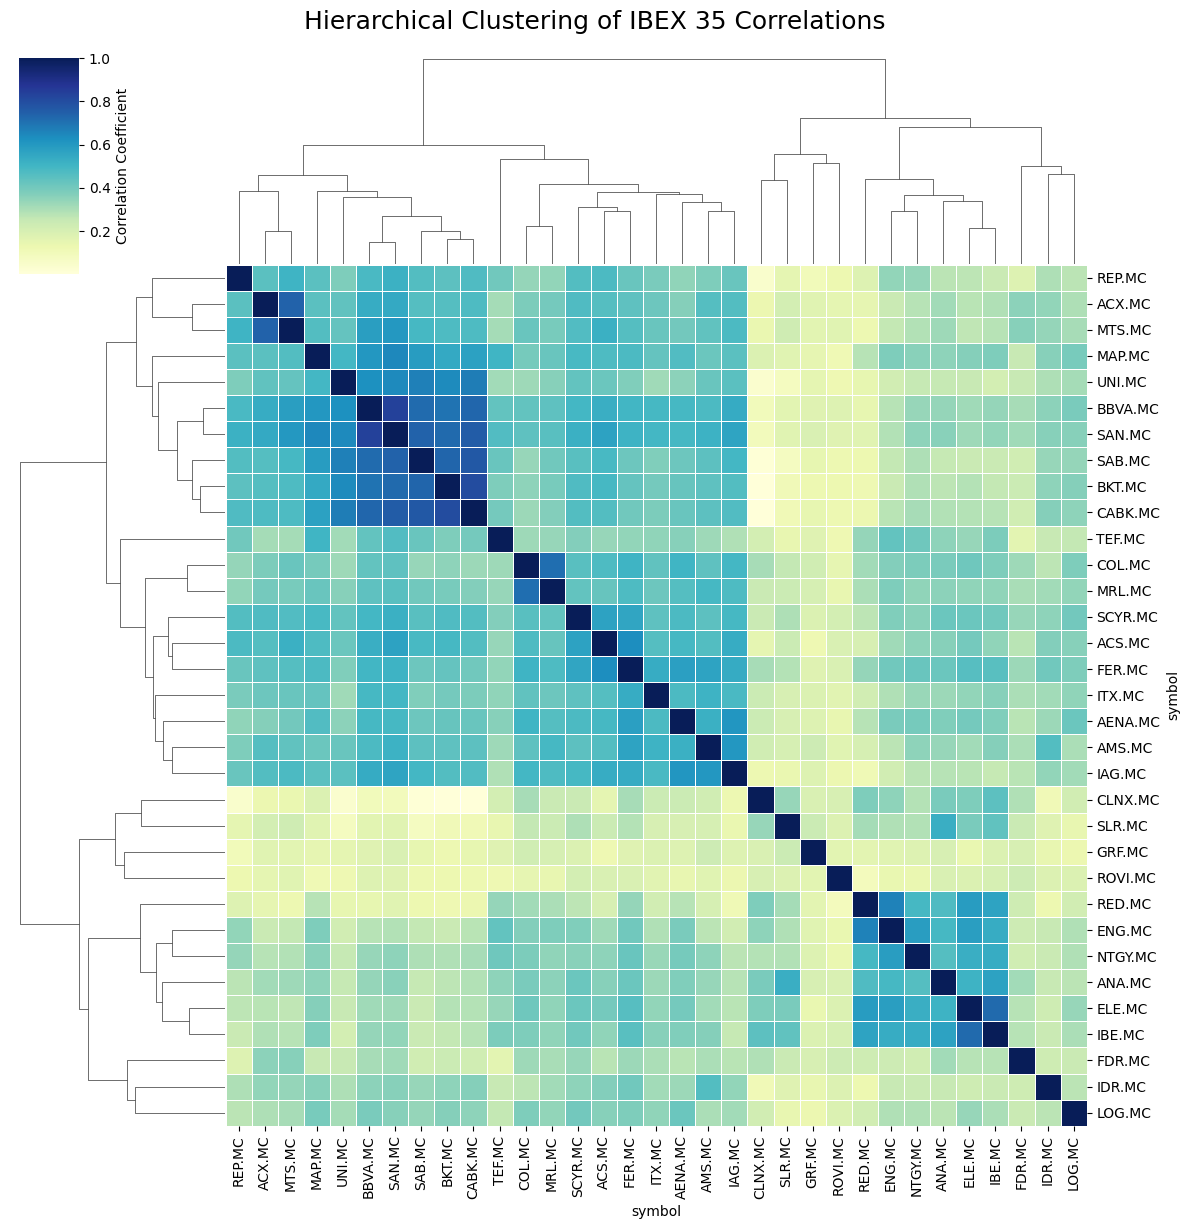

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate Correlation
corr_matrix = returns_df.corr()

# 2. Create a mask for the upper triangle (optional, but cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plotting using Clustermap for automatic sector grouping
# We use 'YlGnBu' (Yellow-Green-Blue) to show correlation strength
g = sns.clustermap(
    corr_matrix,
    cmap='YlGnBu',
    annot=False,
    linewidths=.5,
    figsize=(12, 12),
    cbar_kws={'label': 'Correlation Coefficient'},
    # 'complete' linkage often finds the sector clusters best
    method='complete'
)

# Rotate labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.fig.suptitle('Hierarchical Clustering of IBEX 35 Correlations', fontsize=18, y=1.02)
plt.show()

## Correlations are Not Static!

To end this session, we are going to look at one of the most important concepts in Quantitative Finance: **Correlation Instability**.

Up until now, our Heatmaps and Clustermaps have shown a "Static Average" of the last 6 years. But in the real world, the relationship between two companies changes depending on the economic weather.

### The Aim of this "Playground":
We are comparing **BBVA** (a cyclical bank) with **Enagás (ENG.MC)** (a defensive utility).
* **In "Normal" times:** These two might move independently (low correlation).
* **In "Crisis" times:** Everything tends to crash together, causing correlations to "spike" toward 1.0.

**Why this is the perfect bridge to PCA:**
PCA works because correlations exist, but the *strength* of those correlations shifts. This rolling plot proves that the "Market Factor" (the force that pulls everything together) gets stronger during periods of high stress.

---
**TRY THIS:** Change `stock_A` and `stock_B` in the code above to any two survivors (e.g., `SAN.MC` and `SAB.MC`). You will see that while banks always stay highly correlated, the "Defensive vs. Cyclical" relationships are a wild rollercoaster!

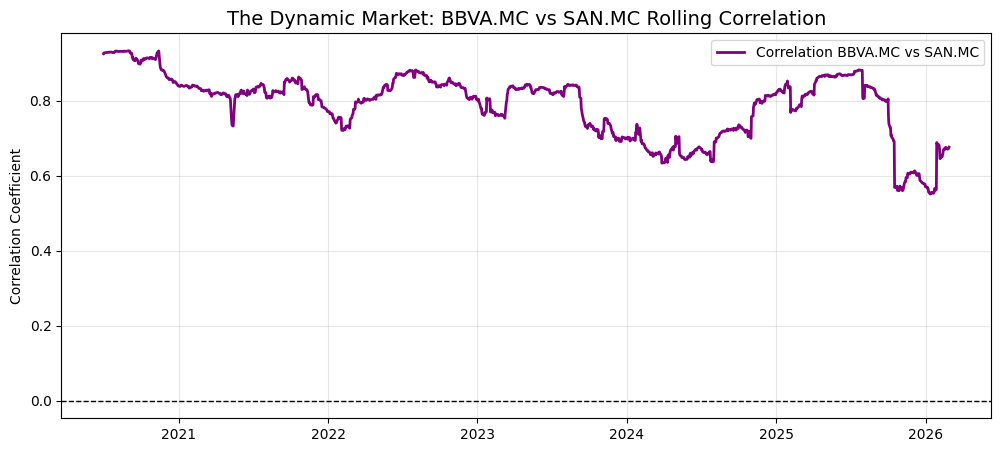

In [ ]:
# 1. Select the two tickers we actually HAVE in our CLEANED dataframe
stock_A = "BBVA.MC"  # The Bank (Cyclical)
stock_B = "SAN.MC"   # Enagás (Defensive / Utility)

# 2. Calculate Rolling Correlation (6-month window = 126 trading days)
# Note: We use the 'returns_df' variable we created earlier!
rolling_corr = returns_df[stock_A].rolling(window=126).corr(returns_df[stock_B])

# 3. Plot it
plt.figure(figsize=(12, 5))
plt.plot(rolling_corr, color='purple', linewidth=2, label=f"Correlation {stock_A} vs {stock_B}")
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title(f"The Dynamic Market: {stock_A} vs {stock_B} Rolling Correlation", fontsize=14)
plt.ylabel("Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()